# Verde River Model Selection and Hyperparameter Tuning

In [19]:
from datetime import datetime
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from Baselines.baselines import NaiveBaseline, SeasonalAverage, SeasonalRandomWalk
from sklearn.metrics import root_mean_squared_error
import itertools
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../Data/FormattedData/Combined_Monthly_Data.csv")
season_length = 12
test_size = int(8.5 * season_length) # Set aside the last 8.5 years as our ultimate testing set.
df_train = df[:-test_size]
df_test = df[-test_size:]

## Verde River Downstream

Selecting most important lags.

In [ ]:
# ==========================================
# 1. FEATURE & DOWNSTREAM LAG CONFIGURATION
# ==========================================
verde_core_features = [
    "Temp_Verde",
    "Precip_Verde",
    "Temp_Maricopa",
    "Precip_Maricopa",
    "Population",
    "IrrigatedLand_Acres",
    "datacenters_TotalMW",
    "datacenters_TotalNum",
    "log_flow_verde_upstream"
]

verde_lags = [
    "log_flow_verde_downstream_lag_1",
    "log_flow_verde_downstream_lag_2",
    "log_flow_verde_downstream_lag_3",
    "log_flow_verde_downstream_lag_4",
    "log_flow_verde_downstream_lag_5",
    "log_flow_verde_downstream_lag_6",
    "log_flow_verde_downstream_lag_7",
    "log_flow_verde_downstream_lag_8",
    "log_flow_verde_downstream_lag_9",
    "log_flow_verde_downstream_lag_10",
    "log_flow_verde_downstream_lag_11",
    "log_flow_verde_downstream_lag_12"
]

models = {
    "randforest": RandomForestRegressor(n_jobs=-1, random_state=123),
    "adaboost": AdaBoostRegressor(random_state=123),
    "gradientboost": GradientBoostingRegressor(random_state=123),
    "xgboost": XGBRegressor(n_jobs=-1, random_state=123),
}

# ==========================================
# 2. DATA PREPARATION & FILE INITIALIZATION
# ==========================================
target = "log_flow_verde_downstream"
all_cols_needed = verde_core_features + verde_lags + [target]
df_model_train = df_train.dropna(subset=all_cols_needed).reset_index(drop=True)

tscv = TimeSeriesSplit(n_splits=5)
n_lags_to_discover = 2
season_length = 12


output_filename = f"verde_downstream_lag_selection.txt"

with open(output_filename, "w") as f:
    f.write("=== VERDE RIVER DOWNSTREAM LAG SELECTION RESULTS ===\n")
    f.write(f"Target: {target}\n{'=' * 50}\n\n")

print("Selecting the best lags to complement the core features...\n")
print(f"Results are backing up in real-time to '{output_filename}'")

# ==========================================
# 3. FORWARD SELECTION COMPUTATION
# ==========================================
for name, model in models.items():
    print(f"Running lag selection optimization for: {name}...")
    current_features = verde_core_features.copy()
    remaining_lags = verde_lags.copy()
    lags_to_use = []

    best_step_baseline_rmses = []

    for step in range(n_lags_to_discover):
        best_score = float("inf")
        best_lag = None
        for lag in remaining_lags:
            features = current_features + [lag]
            rmses = []
            current_loop_baseline_rmses = []
            for train_index, test_index in tscv.split(df_model_train):
                X_tt = df_model_train[features].iloc[train_index]
                y_tt = df_model_train[target].iloc[train_index]

                model.fit(X_tt, y_tt)

                df_model_train_ho = (
                    df_model_train.iloc[test_index]
                    .copy()
                    .reset_index(drop=True)
                )
                y_ho = df_model_train_ho[target]
                preds = np.empty(len(df_model_train_ho))

                for month in range(len(df_model_train_ho)):
                    for lag_idx in range(1, 13):
                        if month >= lag_idx:
                            lag_col_name = (
                                f"log_flow_verde_downstream_lag_{lag_idx}"
                            )
                            df_model_train_ho.loc[month, lag_col_name] = preds[
                                month - lag_idx
                            ]
                    X_timestep = df_model_train_ho[features].iloc[[month]]
                    preds[month] = model.predict(X_timestep)[0]

                rmse = root_mean_squared_error(y_ho, preds)
                rmses.append(rmse)

                # Compute Seasonal Average baseline for this exact fold slice
                ts_tt_baseline = df_model_train[target].iloc[train_index]
                sa = SeasonalAverage(season_length=season_length)
                sa.fit(ts_tt_baseline)
                
                sa_preds = sa.forecast(len(test_index)) 
                baseline_rmse = root_mean_squared_error(y_ho, sa_preds)
                current_loop_baseline_rmses.append(baseline_rmse)

            score = np.mean(rmses)
            if score < best_score:
                best_score = score
                best_lag = lag
                best_step_baseline_rmses = current_loop_baseline_rmses

        current_features.append(best_lag)
        lags_to_use.append(best_lag)
        remaining_lags.remove(best_lag)

    baseline_overall_score = np.mean(best_step_baseline_rmses)

    # Log immediately to file
    with open(output_filename, "a") as f:
        f.write(f"Model Architecture: {name}\n")
        f.write(f"Top {n_lags_to_discover} Selected Lags: {lags_to_use}\n")
        f.write(f"Best Selection Validation RMSE: {best_score:.4f}\n")
        f.write(f"Benchmark Seasonal Average Baseline RMSE: {baseline_overall_score:.4f}\n")
        f.write(f"{'-' * 50}\n")

    print(f"Best Parameters found for {name} feature set: {lags_to_use}")
    print(f"Best Validation RMSE for {name} is {abs(best_score):.4f}")
    print(f"Benchmark Seasonal Average Baseline RMSE is {baseline_overall_score:.4f}")
    print(f"**{'-' * 70}**")

print(f"\nAll models processed successfully! Results saved in '{output_filename}'")

The Verde downstream flow lag selection results can be found in [verde_downstream_lag_selection.txt](verde_downstream_lag_selection.txt).

Next we do hyperparameter tuning for each model, with the best lags.

In [ ]:
# ==========================================
# 1. FEATURE & SPECIFIC MODEL LAG POOLS
# ==========================================
verde_core_features = [
    "Temp_Verde",
    "Precip_Verde",
    "Temp_Maricopa",
    "Precip_Maricopa",
    "Population",
    "IrrigatedLand_Acres",
    "datacenters_TotalMW",
    "datacenters_TotalNum",
    "log_flow_verde_upstream"
]

verde_lags = [
    "log_flow_verde_downstream_lag_1",
    "log_flow_verde_downstream_lag_2",
    "log_flow_verde_downstream_lag_3",
    "log_flow_verde_downstream_lag_4",
    "log_flow_verde_downstream_lag_5",
    "log_flow_verde_downstream_lag_6",
    "log_flow_verde_downstream_lag_7",
    "log_flow_verde_downstream_lag_8",
    "log_flow_verde_downstream_lag_9",
    "log_flow_verde_downstream_lag_10",
    "log_flow_verde_downstream_lag_11",
    "log_flow_verde_downstream_lag_12"
]

rf_lags = ['log_flow_verde_downstream_lag_4', 'log_flow_verde_downstream_lag_12']
ada_lags = ['log_flow_verde_downstream_lag_6', 'log_flow_verde_downstream_lag_1']
gradient_lags = ['log_flow_verde_downstream_lag_4', 'log_flow_verde_downstream_lag_2']
xg_lags = ['log_flow_verde_downstream_lag_6', 'log_flow_verde_downstream_lag_5']

unique_lags = list(set().union(rf_lags, ada_lags, gradient_lags, xg_lags))

models = {
    "randforest": {
        "model": RandomForestRegressor,
        "lags": rf_lags,
        "static_params": {"random_state": 123, "n_jobs": -1},
        "grid": {"max_depth": range(1, 11), "n_estimators": [100, 500]},
    },
    "adaboost": {
        "model": AdaBoostRegressor,
        "lags": ada_lags,
        "static_params": {"random_state": 123},
        "grid": {"n_estimators": [50, 100, 200], "learning_rate": [0.01, 0.1]},
    },
    "gradientboost": {
        "model": GradientBoostingRegressor,
        "lags": gradient_lags,
        "static_params": {"random_state": 123},
        "grid": {"max_depth": range(1, 11), "n_estimators": [100, 500]},
    },
    "xgboost": {
        "model": XGBRegressor,
        "lags": xg_lags,
        "static_params": {"random_state": 42, "n_jobs": -1},
        "grid": {"max_depth": range(1, 11), "n_estimators": [100, 500]},
    },
}

# ==========================================
# 2. DATA PREPARATION & LOG INITIALIZATION
# ==========================================
target = "log_flow_verde_downstream"
all_cols_needed = verde_core_features + verde_lags + [target]
df_model_train = df_train.dropna(subset=all_cols_needed).reset_index(drop=True)

ts_cv = TimeSeriesSplit(n_splits=5)
season_length = 12

# Generate filename for this execution run
output_filename = f"verde_downstream_grid_search_summary.txt"

# Open in write mode once at the top to instantiate the file header
with open(output_filename, "w") as f:
    f.write("=== VERDE DOWNSTREAM GRID SEARCH RESULTS ===\n")
    f.write(f"{'=' * 60}\n\n")

print(f"Grid search optimized. Exporting summary updates to: '{output_filename}'\n")

# ==========================================
# 3. TUNING AND HYPERPARAMETER OPTIMIZATION
# ==========================================
for name, info in models.items():
    print(f"Running grid search optimization for: {name}...")
    lags = info["lags"]

    grid_keys = list(info["grid"].keys())
    grid_values = list(info["grid"].values())
    combinations = [
        dict(zip(grid_keys, v)) for v in itertools.product(*grid_values)
    ]

    features = verde_core_features + lags

    best_score = float("inf")
    best_params = None
    best_step_baseline_rmses = []

    for combination in combinations:
        model = info["model"](**{**info["static_params"], **combination})
        rmses = []
        current_loop_baseline_rmses = []


        for train_index, test_index in ts_cv.split(df_model_train):
            X_tt = df_model_train[features].iloc[train_index]
            y_tt = df_model_train[target].iloc[train_index]

            model.fit(X_tt, y_tt)

            df_model_train_ho = (
                df_model_train.iloc[test_index].copy().reset_index(drop=True)
            )
            y_ho = df_model_train_ho[target]
            preds = np.empty(len(df_model_train_ho))

            # Month-by-month predictions
            for month in range(len(df_model_train_ho)):
                for lag_idx in range(1, 13):
                    if month >= lag_idx:
                        lag_col_name = f"log_flow_verde_downstream_lag_{lag_idx}"
                        df_model_train_ho.loc[month, lag_col_name] = preds[
                            month - lag_idx
                        ]

                X_timestep = df_model_train_ho[features].iloc[[month]]
                preds[month] = model.predict(X_timestep)[0]

            # Calculate rmse for this fold
            rmse = root_mean_squared_error(y_ho, preds)
            rmses.append(rmse)

            # Compute Seasonal Average baseline for this fold
            ts_tt_baseline = df_model_train[target].iloc[train_index]
            sa = SeasonalAverage(season_length=season_length)
            sa.fit(ts_tt_baseline)
                
            sa_preds = sa.forecast(len(test_index)) 
            baseline_rmse = root_mean_squared_error(y_ho, sa_preds)
            current_loop_baseline_rmses.append(baseline_rmse)

        score = np.mean(rmses)
        if score < best_score:
            best_score = score
            best_params = combination
            best_step_baseline_rmses = current_loop_baseline_rmses

    baseline_overall_score = np.mean(best_step_baseline_rmses)
    # Append parameters to our text log
    with open(output_filename, "a") as f:
        f.write(f"Model Architecture: {name}\n")
        f.write(f"Best Parameters Found: {best_params}\n")
        f.write(f"Best Recursive Cross-Validation RMSE: {abs(best_score):.4f}\n")
        f.write(f"Benchmark Seasonal Average Baseline RMSE: {baseline_overall_score:.4f}\n")
        f.write(f"{'-' * 70}\n")

    print(f"Best Parameters found for {name} are {best_params}")
    print(f"Best Validation RMSE for {name} is {abs(best_score):.4f}")
    print(f"Benchmark Seasonal Average Baseline RMSE is {baseline_overall_score:.4f}")
    print(f"**{'-' * 70}**")

print(f"\nAll operations complete! Results are stored inside your custom text file: '{output_filename}'")

The Verde downstream hyperparameter tuning results can be found in [verde_downstream_grid_search_summary.txt](verde_downstream_grid_search_summary.txt).

Now we fit the final model on the training data and look at feature importance.

In [3]:
# ==========================================
# 1. FEATURE & LAG CONFIGURATION
# ==========================================
verde_downstream_features = [
    "Temp_Verde",
    "Precip_Verde",
    "Temp_Maricopa",
    "Precip_Maricopa",
    "Population",
    "IrrigatedLand_Acres",
    "datacenters_TotalMW",
    "datacenters_TotalNum",
    "log_flow_verde_upstream",
    "log_flow_verde_downstream_lag_5",
    "log_flow_verde_downstream_lag_6"
]

verde_lags = [
    "log_flow_verde_downstream_lag_1",
    "log_flow_verde_downstream_lag_2",
    "log_flow_verde_downstream_lag_3",
    "log_flow_verde_downstream_lag_4",
    "log_flow_verde_downstream_lag_5",
    "log_flow_verde_downstream_lag_6",
    "log_flow_verde_downstream_lag_7",
    "log_flow_verde_downstream_lag_8",
    "log_flow_verde_downstream_lag_9",
    "log_flow_verde_downstream_lag_10",
    "log_flow_verde_downstream_lag_11",
    "log_flow_verde_downstream_lag_12"
]

# ==========================================
# 2. DATA CLEANING & TARGET ISOLATION
# ==========================================
target = "log_flow_verde_downstream"
all_cols_needed = verde_downstream_features + verde_lags + [target]
df_model_train = df_train.dropna(subset=all_cols_needed).reset_index(drop=True)

# ==========================================
# 3. MODEL INITIALIZATION & TRAINING
# ==========================================
verde_downstream_model = XGBRegressor(max_depth=6, n_estimators=100)

verde_downstream_model.fit(df_model_train[verde_downstream_features], df_model_train[target])

print("Model trained successfully on the historical data matrix!")
print()

# ==========================================
# 4. MODEL IMPORTANCES
# ==========================================

print("Model feature importances:")
model_importances = {v: float(verde_downstream_model.feature_importances_[i]) for (i,v) in enumerate(verde_downstream_features)}
sorted_model_importances = dict(sorted(model_importances.items(), key= lambda item: item[1], reverse=True))

sorted_model_importances

Model trained successfully on the historical data matrix!

Model feature importances:


{'log_flow_verde_upstream': 0.29463768005371094,
 'IrrigatedLand_Acres': 0.17727959156036377,
 'Population': 0.11378706246614456,
 'log_flow_verde_downstream_lag_5': 0.08568409830331802,
 'Precip_Maricopa': 0.07908855378627777,
 'Temp_Maricopa': 0.07833734154701233,
 'log_flow_verde_downstream_lag_6': 0.07410061359405518,
 'Precip_Verde': 0.050305310636758804,
 'Temp_Verde': 0.04618663713335991,
 'datacenters_TotalMW': 0.0005930206971243024,
 'datacenters_TotalNum': 0.0}

## Verde Upstream Flow

Finding most important lags.

In [ ]:
from datetime import datetime

# ==========================================
# 1. FEATURE & MODEL CONFIGURATION
# ==========================================
verde_upstream_core_features = [
    # Core Base Features
    "Temp_Verde",
    "Precip_Verde",
]

verde_upstream_lags = [
    # Verde Upstream lags
    "log_flow_verde_upstream_lag_1",
    "log_flow_verde_upstream_lag_2",
    "log_flow_verde_upstream_lag_3",
    "log_flow_verde_upstream_lag_4",
    "log_flow_verde_upstream_lag_5",
    "log_flow_verde_upstream_lag_6",
    "log_flow_verde_upstream_lag_7",
    "log_flow_verde_upstream_lag_8",
    "log_flow_verde_upstream_lag_9",
    "log_flow_verde_upstream_lag_10",
    "log_flow_verde_upstream_lag_11",
    "log_flow_verde_upstream_lag_12",
]

models = {
    "randforest": RandomForestRegressor(n_jobs=-1, random_state=123),
    "adaboost": AdaBoostRegressor(random_state=123),
    "gradientboost": GradientBoostingRegressor(random_state=123),
    "xgboost": XGBRegressor(n_jobs=-1, random_state=123),
}

# ==========================================
# 2. DATA PREPARATION & LOG FILE INITIALIZATION
# ==========================================
all_cols_needed = (
    verde_upstream_core_features + verde_upstream_lags + ["log_flow_verde_upstream"]
)
df_model_train = df_train.dropna(subset=all_cols_needed).reset_index(drop=True)

tscv = TimeSeriesSplit(n_splits=5)
n_lags_to_discover = 2
season_length = 12
target = 'log_flow_verde_upstream'

# Create a filename for this selection run
output_filename = f"verde_upstream_lag_selection.txt"

with open(output_filename, "w") as f:
    f.write("=== VERDE RIVER UPSTREAM LAG SELECTION RESULTS ===\n")
    f.write(f"{'=' * 50}\n\n")

print(f"Selecting the best lags to complement the core features...")
print(f"Real-time backup logging to: '{output_filename}'\n")

# ==========================================
# 3. FORWARD SELECTION PROCESSING LOOP
# ==========================================
for name, model in models.items():
    print(f"Processing lag discovery iterations for model: {name}...")
    current_features = verde_upstream_core_features.copy()
    remaining_lags = verde_upstream_lags.copy()
    lags_to_use = []
    best_step_baseline_rmses = []

    for step in range(n_lags_to_discover):
        best_score = float("inf")
        best_lag = None
        
        for lag in remaining_lags:
            features = current_features + [lag]
            rmses = []
            current_loop_baseline_rmses = []

            
            for train_index, test_index in tscv.split(df_model_train):
                X_tt = df_model_train[features].iloc[train_index]
                y_tt = df_model_train["log_flow_verde_upstream"].iloc[train_index]

                model.fit(X_tt, y_tt)

                df_model_train_ho = (
                    df_model_train.iloc[test_index].copy().reset_index(drop=True)
                )
                y_ho = df_model_train_ho.log_flow_verde_upstream
                preds = np.empty(len(df_model_train_ho))

                for month in range(len(df_model_train_ho)):
                    for lag_idx in range(1, 13):
                        if month >= lag_idx:
                            lag_col_name = f"log_flow_verde_upstream_lag_{lag_idx}"
                            df_model_train_ho.loc[month, lag_col_name] = preds[
                                month - lag_idx
                            ]
                    X_timestep = df_model_train_ho[features].iloc[[month]]
                    preds[month] = model.predict(X_timestep)[0]

                rmse = root_mean_squared_error(y_ho, preds)
                rmses.append(rmse)

                # Compute Seasonal Average baseline for this fold
                ts_tt_baseline = df_model_train[target].iloc[train_index]
                sa = SeasonalAverage(season_length=season_length)
                sa.fit(ts_tt_baseline)
                
                sa_preds = sa.forecast(len(test_index)) 
                baseline_rmse = root_mean_squared_error(y_ho, sa_preds)
                current_loop_baseline_rmses.append(baseline_rmse)

            score = np.mean(rmses)
            if score < best_score:
                best_score = score
                best_lag = lag
                best_step_baseline_rmses = current_loop_baseline_rmses
                

        current_features.append(best_lag)
        lags_to_use.append(best_lag)
        remaining_lags.remove(best_lag)

    baseline_overall_score = np.mean(best_step_baseline_rmses)

    # Append parameters to our text log
    with open(output_filename, "a") as f:
        f.write(f"Model: {name}\n")
        f.write(f"Discovered Optimal Lags: {lags_to_use}\n")
        f.write(f"Best Average RMSE: {best_score:.4f}\n")
        f.write(f"Benchmark Seasonal Average Baseline RMSE: {baseline_overall_score:.4f}\n")
        f.write(f"{'-' * 50}\n")

    print(f"Best Parameters found for {name} feature set: {lags_to_use}")
    print(f"Best Validation RMSE for {name} is {abs(best_score):.4f}")
    print(f"Benchmark Seasonal Average Baseline RMSE is {baseline_overall_score:.4f}")
    print(f"**{'-' * 70}**")

print(f"\nOptimization cycle complete! Open '{output_filename}' to access your results.")

The Verde upstream lag selection results can be found in [verde_upstream_lag_selection.txt](verde_upstream_lag_selection.txt).

Now we do hyperparameter tuning for each model with the selected best lags.

In [ ]:
# ==========================================
# 1. FEATURE & LAG CONFIGURATION
# ==========================================
verde_upstream_core_features = [
    "Temp_Verde",
    "Precip_Verde",
]

verde_upstream_lags = [
    "log_flow_verde_upstream_lag_1",
    "log_flow_verde_upstream_lag_2",
    "log_flow_verde_upstream_lag_3",
    "log_flow_verde_upstream_lag_4",
    "log_flow_verde_upstream_lag_5",
    "log_flow_verde_upstream_lag_6",
    "log_flow_verde_upstream_lag_7",
    "log_flow_verde_upstream_lag_8",
    "log_flow_verde_upstream_lag_9",
    "log_flow_verde_upstream_lag_10",
    "log_flow_verde_upstream_lag_11",
    "log_flow_verde_upstream_lag_12"
]

rf_lags = ['log_flow_verde_upstream_lag_1', 'log_flow_verde_upstream_lag_7']
ada_lags = ['log_flow_verde_upstream_lag_2', 'log_flow_verde_upstream_lag_1']
gradient_lags = ['log_flow_verde_upstream_lag_1', 'log_flow_verde_upstream_lag_11']
xg_lags = ['log_flow_verde_upstream_lag_1', 'log_flow_verde_upstream_lag_4']

unique_lags = list(set().union(rf_lags, ada_lags, gradient_lags, xg_lags))

# ==========================================
# 2. MODEL TUNING CONFIGURATIONS
# ==========================================
models = {
    "randforest": {
        "model": RandomForestRegressor,
        "lags": rf_lags,
        "static_params": {"random_state": 123, "n_jobs": -1},
        "grid": {"max_depth": range(1, 11), "n_estimators": [100, 500]},
    },
    "adaboost": {
        "model": AdaBoostRegressor,
        "lags": ada_lags,
        "static_params": {"random_state": 123},
        "grid": {"n_estimators": [50, 100, 200], "learning_rate": [0.01, 0.1]},
    },
    "gradientboost": {
        "model": GradientBoostingRegressor,
        "lags": gradient_lags,
        "static_params": {"random_state": 123},
        "grid": {"max_depth": range(1, 11), "n_estimators": [100, 500]},
    },
    "xgboost": {
        "model": XGBRegressor,
        "lags": xg_lags,
        "static_params": {"random_state": 42, "n_jobs": -1},
        "grid": {"max_depth": range(1, 11), "n_estimators": [100, 500]},
    },
}

# ==========================================
# 3. DATA PREPARATION & LOG INITIALIZATION
# ==========================================
target = "log_flow_verde_upstream"
all_cols_needed = verde_upstream_core_features + verde_upstream_lags + [target]

df_model_train = df_train.dropna(subset=all_cols_needed).reset_index(drop=True)

ts_cv = TimeSeriesSplit(n_splits=5)
season_length = 12

# Generate a filename for this specific run
output_filename = f"verde_upstream_grid_search_summary.txt"

with open(output_filename, "w") as f:
    f.write("=== VERDE UPSTREAM GRID SEARCH RESULTS ===\n")
    f.write(f"{'=' * 60}\n\n")

print(f"Grid search started. Results will be saved to '{output_filename}'...\n")

# ==========================================
# 4. EXECUTION LOOP WITH FILE WRITING
# ==========================================
for name, info in models.items():
    print(f"Running grid search optimization for: {name}...")
    lags = info["lags"]

    grid_keys = list(info["grid"].keys())
    grid_values = list(info["grid"].values())
    combinations = [
        dict(zip(grid_keys, v)) for v in itertools.product(*grid_values)
    ]

    features = verde_upstream_core_features + lags

    best_score = float("inf")
    best_params = None
    best_step_baseline_rmses = []

    for combination in combinations:
        model = info["model"](**{**info["static_params"], **combination})
        rmses = []
        current_loop_baseline_rmses = []

        for train_index, test_index in ts_cv.split(df_model_train):
            X_tt = df_model_train[features].iloc[train_index]
            y_tt = df_model_train[target].iloc[train_index]

            model.fit(X_tt, y_tt)

            df_model_train_ho = (
                df_model_train.iloc[test_index].copy().reset_index(drop=True)
            )
            y_ho = df_model_train_ho[target]
            preds = np.empty(len(df_model_train_ho))

            # Month-by-month predictions
            for month in range(len(df_model_train_ho)):
                for lag_idx in range(1, 13):
                    if month >= lag_idx:
                        lag_col_name = f"log_flow_verde_upstream_lag_{lag_idx}"
                        df_model_train_ho.loc[month, lag_col_name] = preds[
                            month - lag_idx
                        ]

                X_timestep = df_model_train_ho[features].iloc[[month]]
                preds[month] = model.predict(X_timestep)[0]

            rmse = root_mean_squared_error(y_ho, preds)
            rmses.append(rmse)

            # Compute Seasonal Average baseline for this fold
            ts_tt_baseline = df_model_train[target].iloc[train_index]
            sa = SeasonalAverage(season_length=season_length)
            sa.fit(ts_tt_baseline)
                
            sa_preds = sa.forecast(len(test_index)) 
            baseline_rmse = root_mean_squared_error(y_ho, sa_preds)
            current_loop_baseline_rmses.append(baseline_rmse)

        score = np.mean(rmses)
        if score < best_score:
            best_score = score
            best_params = combination
            best_step_baseline_rmses = current_loop_baseline_rmses

    baseline_overall_score = np.mean(best_step_baseline_rmses)

    # Append results to our text log
    with open(output_filename, "a") as f:
        f.write(f"Model Architecture: {name}\n")
        f.write(f"Best Parameters Found: {best_params}\n")
        f.write(f"Best Recursive Cross-Validation RMSE: {abs(best_score):.4f}\n")
        f.write(f"Benchmark Seasonal Average Baseline RMSE: {baseline_overall_score:.4f}\n")
        f.write(f"{'-' * 70}\n")
        
    print(f"Best Parameters found for {name} are {best_params}")
    print(f"Best Validation RMSE for {name} is {abs(best_score):.4f}")
    print(f"Benchmark Seasonal Average Baseline RMSE is {baseline_overall_score:.4f}")
    print(f"**{'-' * 70}**")

print(f"\nAll models processed successfully! Open '{output_filename}' to view your results.")

The Verde upstream hyperparameter tuning results can be found in [verde_upstream_grid_search_summary.txt](verde_upstream_grid_search_summary.txt).

Now we fit the final model on the training data and look at feature importance.

In [14]:
# ==========================================
# 1. FEATURE & LAG CONFIGURATION
# ==========================================
verde_upstream_features = [
    "Temp_Verde",
    "Precip_Verde",
    "log_flow_verde_upstream_lag_1",
    "log_flow_verde_upstream_lag_11"
]

verde_upstream_lags = [
    "log_flow_verde_upstream_lag_1",
    "log_flow_verde_upstream_lag_2",
    "log_flow_verde_upstream_lag_3",
    "log_flow_verde_upstream_lag_4",
    "log_flow_verde_upstream_lag_5",
    "log_flow_verde_upstream_lag_6",
    "log_flow_verde_upstream_lag_7",
    "log_flow_verde_upstream_lag_8",
    "log_flow_verde_upstream_lag_9",
    "log_flow_verde_upstream_lag_10",
    "log_flow_verde_upstream_lag_11",
    "log_flow_verde_upstream_lag_12"
]

# ==========================================
# 2. DATA CLEANING & TARGET ISOLATION
# ==========================================
target = "log_flow_verde_upstream"
all_cols_needed = verde_upstream_features + verde_upstream_lags + [target]
df_model_train = df_train.dropna(subset=all_cols_needed).reset_index(drop=True)

# ==========================================
# 3. MODEL INITIALIZATION & TRAINING
# ==========================================
verde_upstream_model = GradientBoostingRegressor(max_depth=3, n_estimators=100)

verde_upstream_model.fit(df_model_train[verde_upstream_features], df_model_train[target])

print("Model trained successfully on the historical data matrix!")
print()

# ==========================================
# 4. MODEL IMPORTANCES
# ==========================================

print("Model feature importances:")
model_importances = {v: float(verde_upstream_model.feature_importances_[i]) for (i,v) in enumerate(verde_upstream_features)}
sorted_model_importances = dict(sorted(model_importances.items(), key= lambda item: item[1], reverse=True))

sorted_model_importances

Model trained successfully on the historical data matrix!

Model feature importances:


{'log_flow_verde_upstream_lag_1': 0.3346245862971992,
 'Precip_Verde': 0.3286862958266212,
 'Temp_Verde': 0.30336853764446164,
 'log_flow_verde_upstream_lag_11': 0.03332058023171801}

In [15]:
# 1. Load both datasets
df_history = pd.read_csv("../Data/FormattedData/Combined_Monthly_Data.csv")
df_future = pd.read_csv("../Data/FormattedData/FutureVals_SSP245Climate_and_AllOtherFeatures.csv")

# 2. Define the extra target columns you want to preserve from history
extra_historical_targets = ["log_flow_verde_upstream"]

# 3. Create the historical column alignment frame
# We take columns that match the future file PLUS your two custom target tracks
history_columns_to_keep = list(df_future.columns) + extra_historical_targets

# 4. Extract the top 12 rows with the designated features
df_history_top12 = df_history.tail(20)[history_columns_to_keep].copy()

# 5. Combine them vertically
# Note: Pandas automatically pads the future rows with NaN under the target columns
df_combined = pd.concat([df_history_top12, df_future], axis=0).reset_index(drop=True)

df_combined["log_flow_verde_upstream_lag_1"] = df_combined["log_flow_verde_upstream"].shift(1)
df_combined["log_flow_verde_upstream_lag_11"] = df_combined["log_flow_verde_upstream"].shift(11)

# Verify the framework
print(f"Combined data matrix shape: {df_combined.shape}")
print("\nFirst 15 rows of the target streams:")
print(df_combined.head(24))

Combined data matrix shape: (243, 14)

First 15 rows of the target streams:
          Time  Temp_Salt  Temp_Verde  Temp_Maricopa   Precip_Salt  \
0   2024-10-01  15.919569   16.999180      25.670313  11840.724000   
1   2024-11-01   6.110135    6.659913      14.460714  13165.763000   
2   2024-12-01   6.544944    7.024789      14.216112    672.091800   
3   2025-01-01   1.115836    2.397118      10.363307   1731.196300   
4   2025-02-01   7.697050    8.393605      15.941146   8164.468800   
5   2025-03-01   6.999502    8.167544      16.801775  28291.482000   
6   2025-04-01  10.581228   11.300275      20.151009   8697.487000   
7   2025-05-01  14.989045   16.419300      25.235172   4463.939500   
8   2025-06-01  21.514816   22.437496      30.719877   9493.454000   
9   2025-07-01  22.737514   24.319845      33.034866  32371.848000   
10  2025-08-01  23.253197   24.920830      33.585770  20471.783000   
11  2025-09-01  18.887620   20.004467      29.341875  44300.260000   
12  2025-10-01

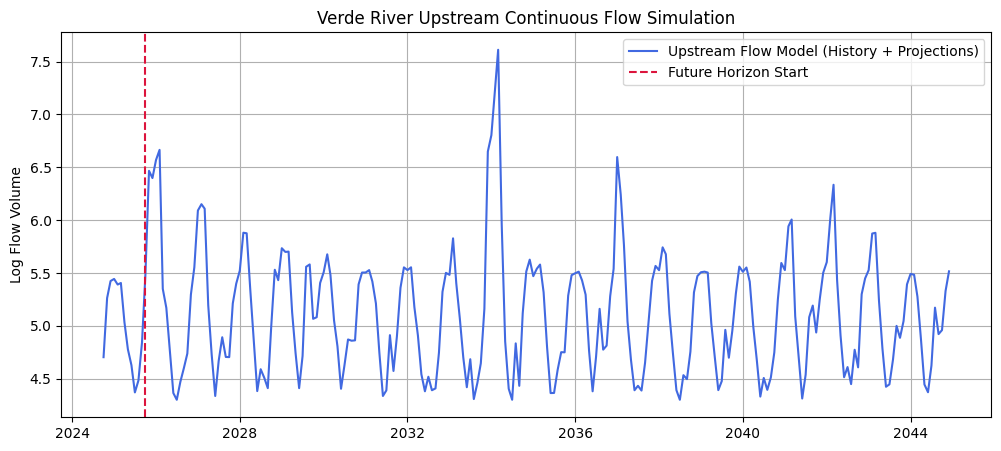

In [20]:
future_predictions = []

verde_upstream_features = [
    "Temp_Verde",
    "Precip_Verde",
    "log_flow_verde_upstream_lag_1",
    "log_flow_verde_upstream_lag_11"
]

for i in range(12,len(df_combined.Time)):
    df_combined.loc[i,'log_flow_verde_upstream_lag_1'] = df_combined.loc[i-1,'log_flow_verde_upstream']
    df_combined.loc[i,'log_flow_verde_upstream_lag_11'] = df_combined.loc[i-11,'log_flow_verde_upstream']
    df_combined.loc[i,'log_flow_verde_upstream'] = verde_upstream_model.predict(df_combined[verde_upstream_features].iloc[[i]])[0]
    

# ==========================================
# 2. PLOTTING THE OUTPUT
# ==========================================
plt.figure(figsize=(12, 5))
plt.plot(
    pd.to_datetime(df_combined["Time"]), 
    df_combined["log_flow_verde_upstream"], 
    label="Upstream Flow Model (History + Projections)", 
    color="royalblue"
)
plt.axvline(pd.to_datetime(df_combined["Time"].iloc[12]), color="crimson", linestyle="--", label="Future Horizon Start")
plt.title("Verde River Upstream Continuous Flow Simulation")
plt.ylabel("Log Flow Volume")
plt.grid(True)
plt.legend()
plt.show()